# Multiclass Classification with Keras (Iris Dataset)

This notebook demonstrates a multiclass classification problem using the famous Iris dataset and Keras.

## 1. Import Libraries

In [1]:
# Thư viện xử lý dữ liệu
import numpy as np
import matplotlib.pyplot as plt

# Thư viện machine learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Thư viện deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

I0000 00:00:1778209783.780424   53118 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778209783.867796   53118 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778209785.486839   53118 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Load and Explore the Iris Dataset

In [2]:
# Tải dữ liệu Iris
iris = load_iris()
X = iris.data        # Đặc trưng
y = iris.target      # Nhãn (0, 1, 2)

# In thông tin cơ bản
print('Feature shape:', X.shape)
print('Target shape:', y.shape)
print('Classes:', iris.target_names)

Feature shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


## 3. Data Preprocessing

In [3]:
# Chia dữ liệu train và test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encoding cho nhãn
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

# Print y_test
print(y_test[:5])

[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


## 4. Build the Neural Network Model

In [4]:
# Khởi tạo mô hình
model = Sequential()

# Tầng ẩn thứ nhất
model.add(Dense(16, activation='relu', input_shape=(4,)))

# Tầng ẩn thứ hai
model.add(Dense(16, activation='relu'))

# Output layer cho bài toán multiclass
model.add(Dense(3, activation='softmax'))

# Compile mô hình
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tóm tắt mô hình
model.summary()

/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778209792.323781   53118 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

In [5]:
# Huấn luyện mô hình
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3229 - loss: 1.1888 - val_accuracy: 0.2917 - val_loss: 1.0066
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3542 - loss: 1.0613 - val_accuracy: 0.5000 - val_loss: 0.8988
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3854 - loss: 0.9487 - val_accuracy: 0.6667 - val_loss: 0.8245
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4896 - loss: 0.8747 - val_accuracy: 0.7917 - val_loss: 0.7631
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7188 - loss: 0.8091 - val_accuracy: 0.7917 - val_loss: 0.7143
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7604 - loss: 0.7612 - val_accuracy: 0.8333 - val_loss: 0.6769
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7708 - loss: 0.7207 - val_accuracy: 0.8750 - val_loss: 0.6403
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7812 - loss: 0.6822 - val_accuracy: 0.8750 - v

## 6. Plot Loss and Accuracy

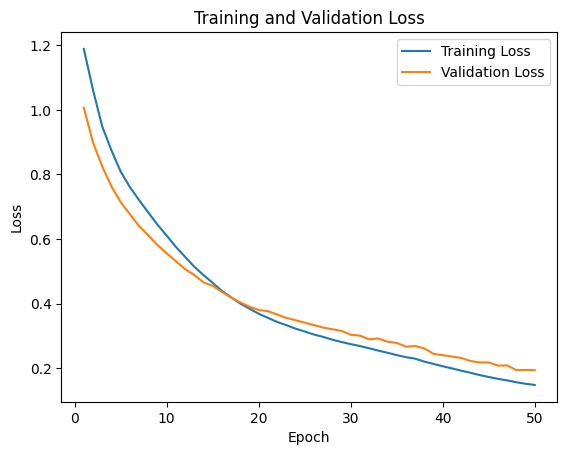

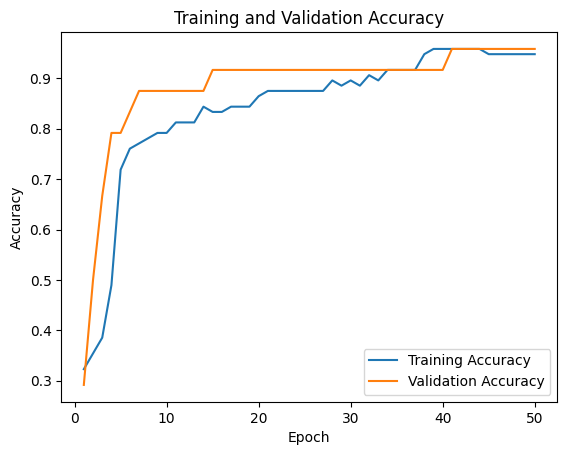

In [6]:
# Lấy dữ liệu từ history
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

# Vẽ đồ thị Loss
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Vẽ đồ thị Accuracy
plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

## 7. Model Evaluation

In [7]:
# Dự đoán trên tập test
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(cm)

# Classification Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=iris.target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 8. Predict on New Samples

In [8]:
# Dữ liệu mới (ví dụ đo hoa)
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.5, 3.0, 5.2, 2.0]
])

# Chuẩn hóa dữ liệu mới
new_samples_scaled = scaler.transform(new_samples)

# Dự đoán
predictions = model.predict(new_samples_scaled)
predicted_classes = np.argmax(predictions, axis=1)

# In kết quả
for i, cls in enumerate(predicted_classes):
    print(f'Sample {i + 1} predicted class:', iris.target_names[cls])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Sample 1 predicted class: setosa
Sample 2 predicted class: virginica


## 9. Confusion Matrix Visualization

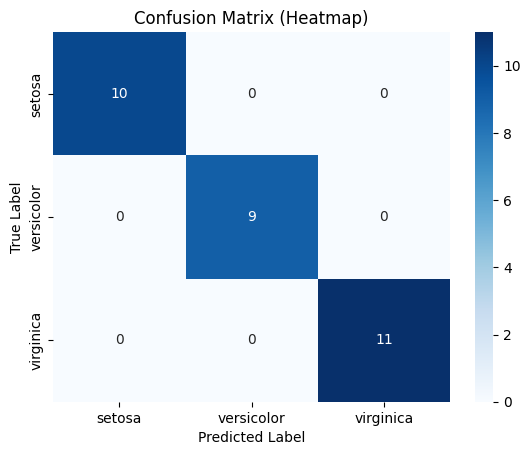

In [9]:
# Thư viện vẽ heatmap
import seaborn as sns

# Vẽ Confusion Matrix dưới dạng heatmap
plt.figure()
sns.heatmap(
    cm,
    annot=True,           # Hiển thị giá trị trong từng ô
    fmt='d',              # Định dạng số nguyên
    cmap='Blues',         # Bảng màu
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Heatmap)')
plt.show()